# **Kmeans Clustering**

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans      # imported for KMeans clustering
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [32]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


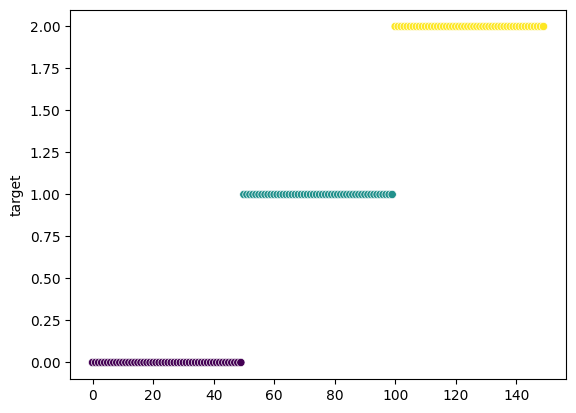

In [33]:
sns.scatterplot(df['target'], c=df['target'])
plt.show()     # as you can see there are 3 clusters

### K-Means Hyperparameters (Scikit-Learn)

| Hyperparameter | Description | Default Value |
| :--- | :--- | :--- |
| **`n_clusters`** | The number of clusters to form ($k$) as well as the number of centroids to generate. | `8` |
| **`init`** | Method for initialization: `'k-means++'` (selects initial cluster centers that are distant from each other), `'random'`, or a provided `ndarray`. | `'k-means++'` |
| **`n_init`** | Number of times the algorithm will be run with different centroid seeds. The final result is the best output of `n_init` runs in terms of inertia. | `'auto'` |
| **`max_iter`** | Maximum number of iterations of the k-means algorithm for a single run. | `300` |
| **`tol`** | Relative tolerance with regards to Frobenius norm of the difference in cluster centers of two consecutive iterations to declare convergence. | `1e-4` |
| **`verbose`** | Verbosity mode for logging progress. | `0` |
| **`random_state`** | Determines random number generation for centroid initialization. Ensures reproducibility. | `None` |
| **`copy_x`** | When True, the original data is not modified. Centering data (if needed) is done on a copy. | `True` |
| **`algorithm`** | K-means algorithm to use: `"lloyd"` (classical EM-style) or `"elkan"` (uses triangle inequality for efficiency). | `"lloyd"` |



In [43]:
wcss = []
# WCSS (Within-Cluster Sum of Squares) is the sum of squared distances between each data point 
# and its assigned cluster centroid. It measures the compactness of the clusters.
# as you can see with every increase in the number of clusters there is decrease in wcss
# with very less number of clusters there is very high wcss

for i in range(1, 11):
    km = KMeans(
        n_clusters=i,
        
    )
    km.fit_predict(df)
    wcss.append(km.inertia_)



In [44]:
wcss

[781.3706,
 179.21554160125595,
 87.22062785114048,
 67.66291891891893,
 50.397857380457395,
 46.27613409778627,
 39.03294227994229,
 34.295708458208466,
 29.45800993124523,
 27.62810626455699]

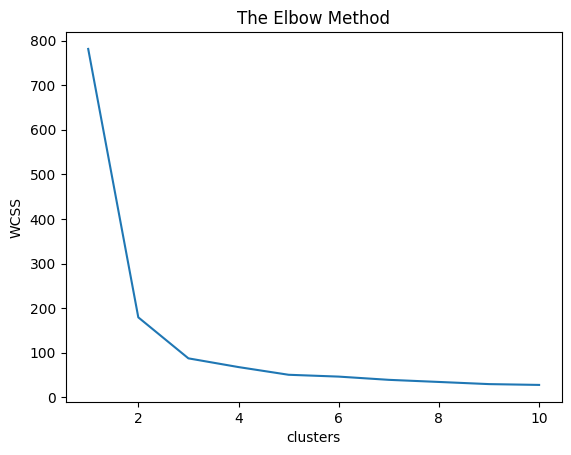

In [45]:
# plotting the wcss graph
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')       # this entire process is called Elbow Method
plt.xlabel('clusters')
plt.ylabel('WCSS')
plt.show()

In [124]:
X = df.iloc[:, :-1].values

km = KMeans(n_clusters=3, random_state=3)
y_means = pd.DataFrame(km.fit_predict(X))

# print(f"CROSS VAL SCORE : {np.round(np.mean(cross_val_score(km, X, y, cv=10, scoring='accuracy')),2)}")
# print(f"ACCCURACY : {accuracy_score(y, y_means)}")
# its completely useless to use cross_val_score or accuracy_scose, as they wil give useless score for KMeans

# print(f"UNIQUE VALUES : {y_means.nunique()}")
print(f"UNIQUE VALUES : {np.unique(km.labels_)}")   # this is the proper way to print unique values in KMeasns
print(f"LABELS : {km.labels_}")

from sklearn.metrics import adjusted_rand_score     # to measure accuracy in KMeans we should use adjusted_rand_score instead of r2 of acccuracy_score
print(f"Adjusted Rand Index: {adjusted_rand_score(y, km.labels_)}")

y_means

UNIQUE VALUES : [0 1 2]
LABELS : [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]
Adjusted Rand Index: 0.7163421126838476


,0
0,1
1,1
2,1
3,1
4,1
...,...
145,2
146,0
147,2
148,2


In [ ]:
X[y_means[0] == 0] # as there are there are 3 clusters we can select the numbers as 0,1,2
# will print data of clluster 0 

[[6.4 3.2 4.5 1.5]
 [5.5 2.3 4.  1.3]
 [6.5 2.8 4.6 1.5]
 [5.7 2.8 4.5 1.3]
 [6.3 3.3 4.7 1.6]
 [4.9 2.4 3.3 1. ]
 [6.6 2.9 4.6 1.3]
 [5.2 2.7 3.9 1.4]
 [5.  2.  3.5 1. ]
 [5.9 3.  4.2 1.5]
 [6.  2.2 4.  1. ]
 [6.1 2.9 4.7 1.4]
 [5.6 2.9 3.6 1.3]
 [6.7 3.1 4.4 1.4]
 [5.6 3.  4.5 1.5]
 [5.8 2.7 4.1 1. ]
 [6.2 2.2 4.5 1.5]
 [5.6 2.5 3.9 1.1]
 [5.9 3.2 4.8 1.8]
 [6.1 2.8 4.  1.3]
 [6.3 2.5 4.9 1.5]
 [6.1 2.8 4.7 1.2]
 [6.4 2.9 4.3 1.3]
 [6.6 3.  4.4 1.4]
 [6.8 2.8 4.8 1.4]
 [6.  2.9 4.5 1.5]
 [5.7 2.6 3.5 1. ]
 [5.5 2.4 3.8 1.1]
 [5.5 2.4 3.7 1. ]
 [5.8 2.7 3.9 1.2]
 [6.  2.7 5.1 1.6]
 [5.4 3.  4.5 1.5]
 [6.  3.4 4.5 1.6]
 [6.7 3.1 4.7 1.5]
 [6.3 2.3 4.4 1.3]
 [5.6 3.  4.1 1.3]
 [5.5 2.5 4.  1.3]
 [5.5 2.6 4.4 1.2]
 [6.1 3.  4.6 1.4]
 [5.8 2.6 4.  1.2]
 [5.  2.3 3.3 1. ]
 [5.6 2.7 4.2 1.3]
 [5.7 3.  4.2 1.2]
 [5.7 2.9 4.2 1.3]
 [6.2 2.9 4.3 1.3]
 [5.1 2.5 3.  1.1]
 [5.7 2.8 4.1 1.3]
 [5.8 2.7 5.1 1.9]
 [4.9 2.5 4.5 1.7]
 [5.7 2.5 5.  2. ]
 [5.8 2.8 5.1 2.4]
 [6.  2.2 5.  1.5]
 [5.6 2.8 4.

In [151]:
X[y_means[0] == 1]  # will print the data of cluster 1 

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [155]:
X[y_means[0] == 0, 0]   # will print the feature at 0th index of the cluster index of 0 

array([6.4, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. , 6.1, 5.6,
       6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1, 6.3, 6.1, 6.4, 6.6, 6.8, 6. ,
       5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6, 5.5, 5.5, 6.1,
       5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7, 5.8, 4.9, 5.7, 5.8, 6. ,
       5.6, 6.3, 6.2, 6.1, 6.3, 6. , 5.8, 6.3, 5.9])

In [157]:
X[y_means[0] == 0, :]   # printing all the features of cluster index of 0 

array([[6.4, 3.2, 4.5, 1.5],
       [5.5, 2.3, 4. , 1.3],
       [6.5, 2.8, 4.6, 1.5],
       [5.7, 2.8, 4.5, 1.3],
       [6.3, 3.3, 4.7, 1.6],
       [4.9, 2.4, 3.3, 1. ],
       [6.6, 2.9, 4.6, 1.3],
       [5.2, 2.7, 3.9, 1.4],
       [5. , 2. , 3.5, 1. ],
       [5.9, 3. , 4.2, 1.5],
       [6. , 2.2, 4. , 1. ],
       [6.1, 2.9, 4.7, 1.4],
       [5.6, 2.9, 3.6, 1.3],
       [6.7, 3.1, 4.4, 1.4],
       [5.6, 3. , 4.5, 1.5],
       [5.8, 2.7, 4.1, 1. ],
       [6.2, 2.2, 4.5, 1.5],
       [5.6, 2.5, 3.9, 1.1],
       [5.9, 3.2, 4.8, 1.8],
       [6.1, 2.8, 4. , 1.3],
       [6.3, 2.5, 4.9, 1.5],
       [6.1, 2.8, 4.7, 1.2],
       [6.4, 2.9, 4.3, 1.3],
       [6.6, 3. , 4.4, 1.4],
       [6.8, 2.8, 4.8, 1.4],
       [6. , 2.9, 4.5, 1.5],
       [5.7, 2.6, 3.5, 1. ],
       [5.5, 2.4, 3.8, 1.1],
       [5.5, 2.4, 3.7, 1. ],
       [5.8, 2.7, 3.9, 1.2],
       [6. , 2.7, 5.1, 1.6],
       [5.4, 3. , 4.5, 1.5],
       [6. , 3.4, 4.5, 1.6],
       [6.7, 3.1, 4.7, 1.5],
       [6.3, 2

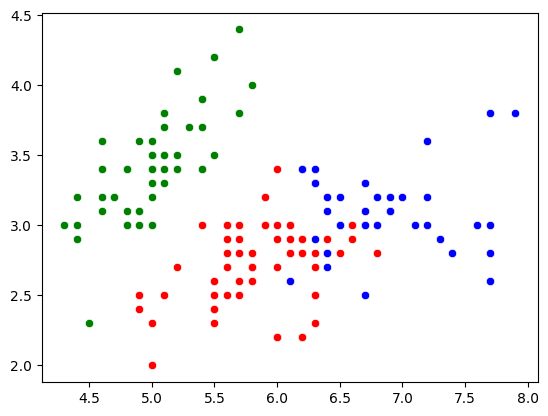

In [158]:
sns.scatterplot(x=X[y_means[0] == 0,0], y=X[y_means[0] == 0,1], color='red')
sns.scatterplot(x=X[y_means[0] == 1,0], y=X[y_means[0] == 1,1], color='green')
sns.scatterplot(x=X[y_means[0] == 2,0], y=X[y_means[0] == 2,1], color='blue')
plt.show()